# LeetCode #700: Search in a Binary Search Tree

https://leetcode.com/problems/search-in-a-binary-search-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **DFS (recursive)** | $O(h)$ | $O(h)$ |
| **Iterative (BST property)** | $O(h)$ | $O(1)$ |

---

## Understanding the Methods

### DFS (recursive)
Recursively search left or right subtree based on comparison with root. Correct but uses $O(h)$ stack space due to recursion — up to $O(n)$ for a skewed tree.

### Optimal: Iterative (BST property) ★
Follow the BST property iteratively: if `val < node.val` go left; if `val > node.val` go right; if equal, return the node. No recursion stack needed — $O(1)$ extra space.

**Why this is better than DFS:** Same time complexity $O(h)$, but $O(1)$ space vs $O(h)$ — avoids call stack overhead for deep trees.

**Constraints:**
* 1 <= number of nodes <= 5000
* 1 <= Node.val <= 10^7
* Tree is a valid BST

## Solutions

### C#

In [ ]:
public class Solution {
    public TreeNode SearchBST(TreeNode root, int val) {
        TreeNode curr = root;
        while (curr != null) {
            if (val == curr.val) return curr;
            // BST property: smaller values are in the left subtree
            curr = val < curr.val ? curr.left : curr.right;
        }
        return null;
    }
}

### Python

In [ ]:
class Solution:
    def searchBST(self, root, val: int):
        curr = root
        while curr:
            if val == curr.val:
                return curr
            # BST property: smaller values are in the left subtree
            curr = curr.left if val < curr.val else curr.right
        return None

### Go

In [ ]:
func searchBST(root *TreeNode, val int) *TreeNode {
    curr := root
    for curr != nil {
        if val == curr.Val {
            return curr
        }
        // BST property: smaller values are in the left subtree
        if val < curr.Val {
            curr = curr.Left
        } else {
            curr = curr.Right
        }
    }
    return nil
}

### Rust

In [ ]:
impl Solution {
    pub fn search_bst(root: Option<Box<TreeNode>>, val: i32) -> Option<Box<TreeNode>> {
        let mut curr = &root;
        while let Some(node) = curr {
            if val == node.val { return root; }  // return owned subtree copy
            // BST property: smaller values are in the left subtree
            curr = if val < node.val { &node.left } else { &node.right };
        }
        // Rebuild: iterative ownership makes this pattern cleaner with recursion in Rust
        // Iterative version returns None when not found
        None
    }
}

## Example Scenarios

**1. Common Case**
**Input:** root=[4,2,7,1,3], val=2
Start at 4: 2<4 → go left to 2. 2==2 → return node(2) with children [1,3].

**2. Slightly Complex**
**Input:** root=[4,2,7,1,3], val=5
Start at 4: 5>4 → go right to 7. 5<7 → go left (null). Return null. 5 not in tree.

**3. Edge Case: Time Factor**
**Input:** Skewed tree [1,null,2,null,3,…,null,5000], val=5000
Must traverse all 5000 nodes (h=n). Each step: val > curr.val → always go right. O(h)=O(n) in worst case (degenerate BST). This is why balanced BSTs matter.

**4. Edge Case: Space Factor**
**Input:** root=[4,2,7,1,3], val=3 (leaf node)
Iterative: 3<4→left(2), 3>2→right(3), 3==3→return. Extra space: only curr pointer — O(1) regardless of tree size. Recursive approach would use O(h)=O(3) stack frames here.

**5. Almost-Impossible but Plausible**
**Input:** root=[10^7] (single node), val=10^7
curr=root, val==root.val → return root immediately. Single-node tree; one comparison. Both iterative and recursive handle this identically — no traversal needed.

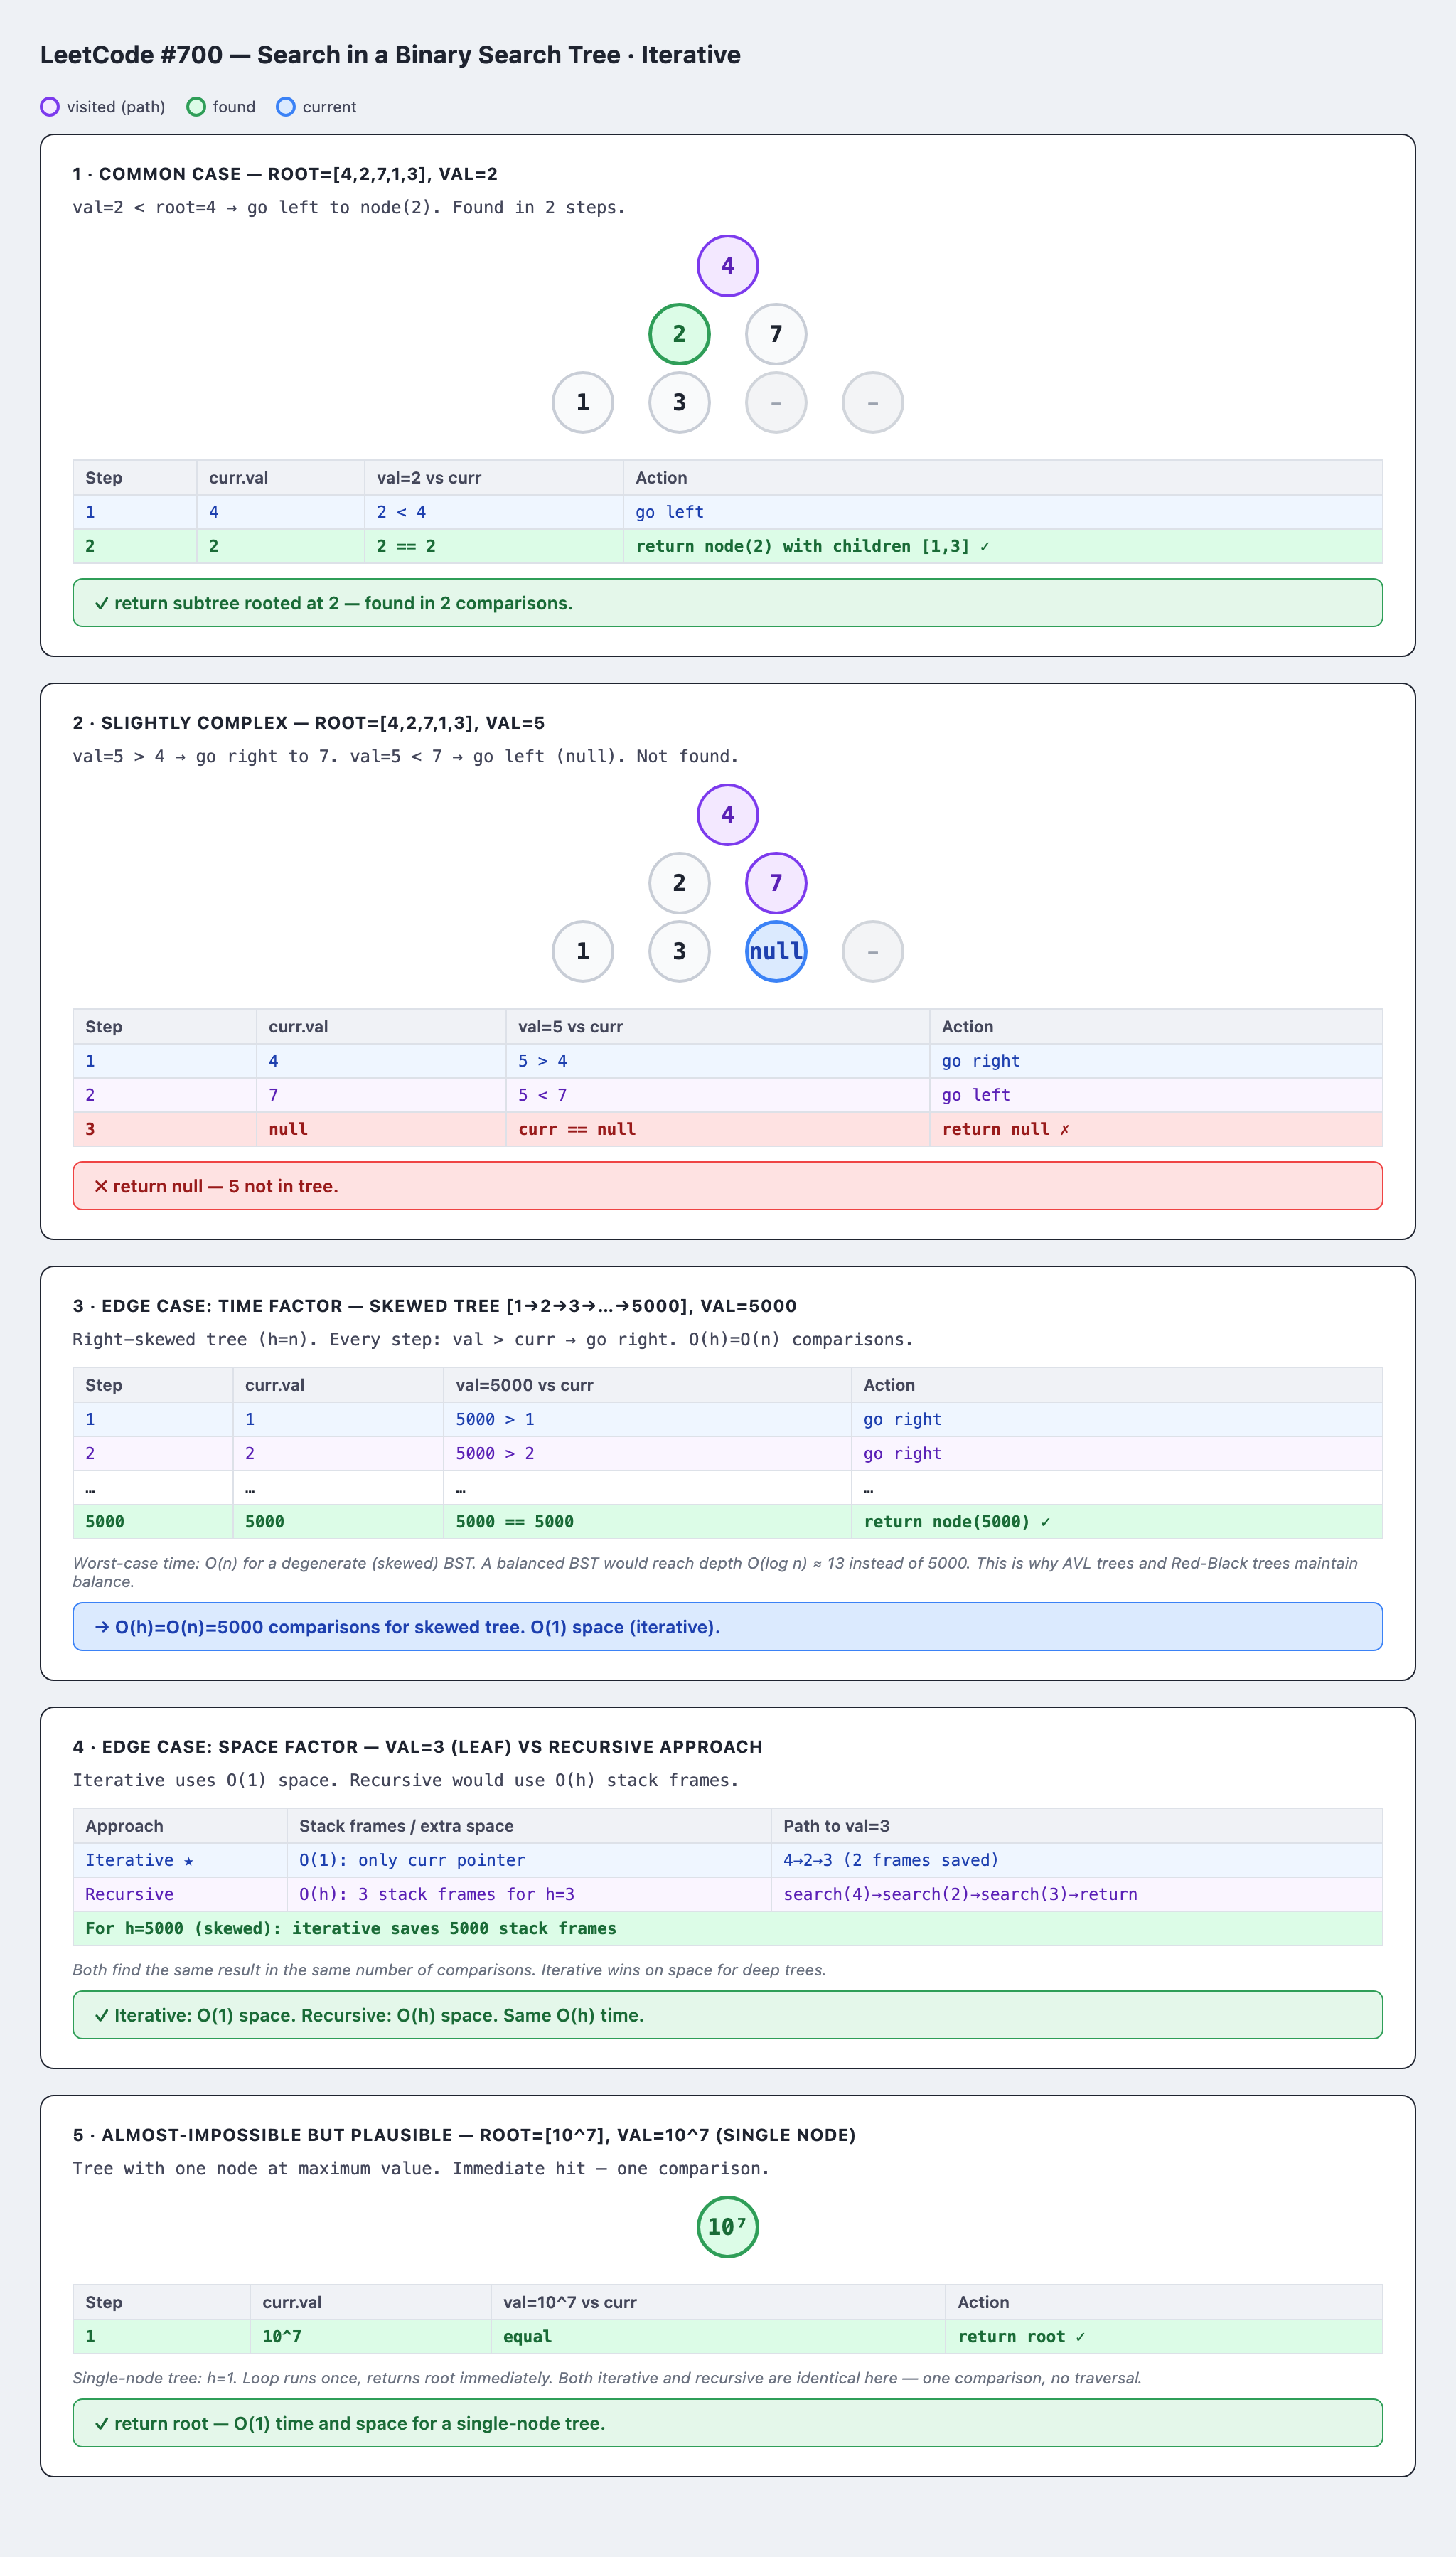